In [1]:

import tkinter as tk
from tkinter import filedialog
import os
import cv2
import numpy as np
from cv2ellipse import *
from forces import *

# Hide the root Tk window

root = tk.Tk()
root.withdraw()
root.attributes("-topmost", True)
# Ask user to pick a folder
image_path = filedialog.askopenfilename(
    title="Select an image file",
    filetypes=[("Image files", "*.jpg;*.jpeg;*.png;*.tif;*.bmp")],
)
if not image_path:
    print("No file selected.")
    exit()


results = []

# Process images



Processing frame_0004.tif…
Select ROI and press ENTER or SPACE. Press ESC to cancel.


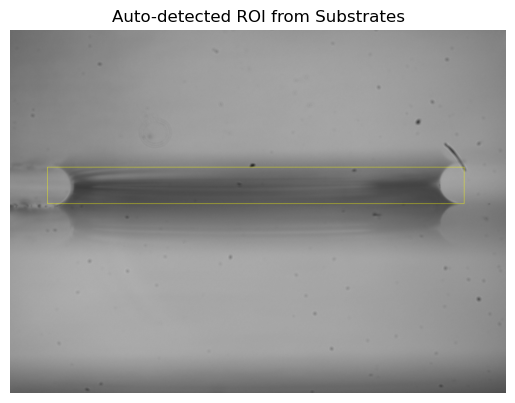

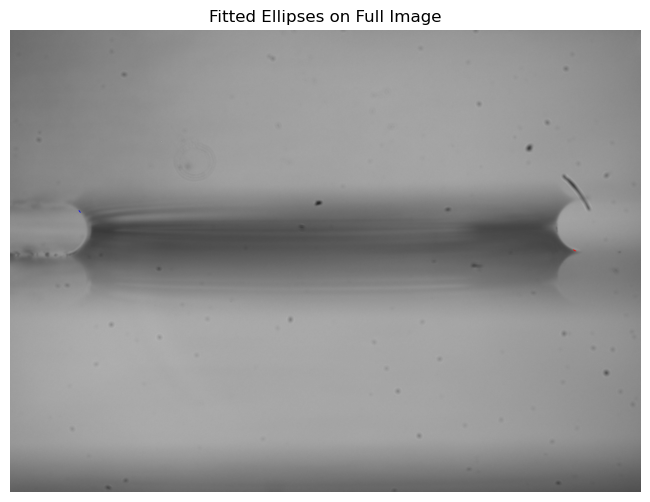

In [4]:
print(f"\nProcessing {os.path.basename(image_path)}…")
result = process_droplet_two_lobes(image_path, roi_type="manual", canny_thresh=(20,20))
if not result:
    print(f"stopping {os.path.basename(image_path)} due to processing failure.")
    exit()


In [ ]:

# Unpack results
ellipse_left, ellipse_right, (x_min, y_min, x_max, y_max), image, cropped = result
roi_height, roi_width = y_max - y_min, x_max - x_min

# Contact angle analysis
left_contacts = extract_all_contact_angles(
    ellipse_left, 0, cropped.shape[0] - 1, "left"
)

right_contacts = extract_all_contact_angles(
    ellipse_right, 0, cropped.shape[0], "right"
)



In [ ]:
def get_meridonal_profile_new(points, contacts, side):
    """
    Extract the meridional profile points from an ellipse fit.
    `points` are (x, y) ellipse points.
    `contacts` is a dictionary with 'top' and 'bottom' keys, each with a 'point': (x, y)
    `side` is either 'left' or 'right'
    """
    top_contact = contacts["top"]['point']
    bottom_contact = contacts["bottom"]['point']

    if side == 'left':
        mask = (
            (points[:, 0] > min(top_contact[0], bottom_contact[0])) &
            (points[:, 1] > top_contact[1]) &
            (points[:, 1] < bottom_contact[1])
        )
        print(mask)
    elif side == 'right':
        mask = (
            (points[:, 0] < max(top_contact[0], bottom_contact[0])) &
            (points[:, 1] > top_contact[1]) &
            (points[:, 1] < bottom_contact[1])
        )
    else:
        raise ValueError("side must be 'left' or 'right'")

    return points[mask]


In [ ]:
ellipse_left_points = ellipse_to_points(*ellipse_left)
ellipse_right_points = ellipse_to_points(*ellipse_right)

TypeError: cv2ellipse.ellipse_to_points() argument after * must be an iterable, not NoneType

In [ ]:
left_meriodonal = get_meridonal_profile_new(
    ellipse_left_points, left_contacts, "left"
)
right_meriodonal = get_meridonal_profile_new(
    ellipse_right_points, right_contacts, "right"
)


NameError: name 'ellipse_left_points' is not defined

In [ ]:
left_meriodonal

array([], shape=(0, 2), dtype=float64)

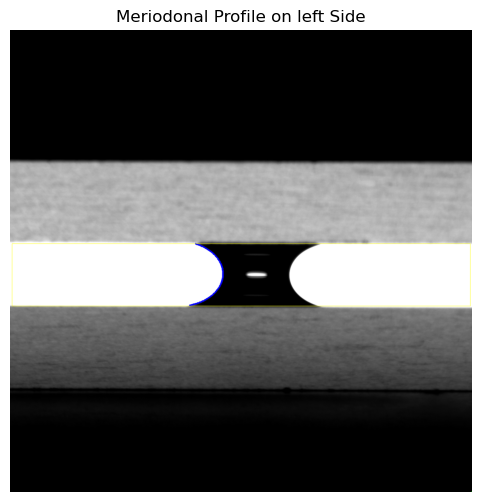

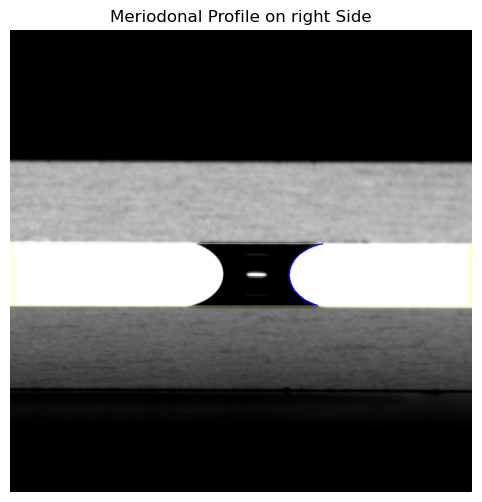

Left contacts: {'top': {'point': array([4.82054878e+02, 2.37896286e-01]), 'angle_deg': np.float64(-16.109754866515445)}, 'bottom': {'point': array([466.15934821, 162.94953065]), 'angle_deg': np.float64(10.280177601228585)}}
Right contacts: {'top': {'point': array([ 8.20246775e+02, -1.44218628e-01]), 'angle_deg': np.float64(9.727793016454223)}, 'bottom': {'point': array([806.76993072, 163.77781167]), 'angle_deg': np.float64(-15.661454749044614)}}


In [ ]:
draw_meriodonal_profile(
    full_image= image.copy(), roi_coords=(x_min, y_min, x_max, y_max), profile_points = left_meriodonal, side ="left"
)
draw_meriodonal_profile(
    full_image= image.copy(), roi_coords=(x_min, y_min, x_max, y_max), profile_points = right_meriodonal, side ="right"
)

print(f"Left contacts: {left_contacts}")
print(f"Right contacts: {right_contacts}")
# Geometric analysis
origin, l_pt, r_pt, min_dist = compute_curve_distance(ellipse_left, ellipse_right)

In [ ]:
left_meriodonal

array([[483.95693561,   0.81543285],
       [485.84499925,   1.41710419],
       [487.7184908 ,   2.042726  ],
       [489.5768364 ,   2.69210666],
       [491.41946682,   3.36504725],
       [493.24581765,   4.06134165],
       [495.05532945,   4.78077656],
       [496.84744797,   5.52313164],
       [498.62162425,   6.28817947],
       [500.37731486,   7.07568574],
       [502.113982  ,   7.8854092 ],
       [503.83109372,   8.71710184],
       [505.52812406,   9.5705089 ],
       [507.2045532 ,  10.44536898],
       [508.85986763,  11.3414141 ],
       [510.49356031,  12.25836979],
       [512.10513084,  13.19595518],
       [513.69408556,  14.15388307],
       [515.25993778,  15.13186006],
       [516.80220785,  16.12958657],
       [518.32042337,  17.14675699],
       [519.81411929,  18.18305976],
       [521.28283808,  19.23817744],
       [522.72612986,  20.31178684],
       [524.14355253,  21.4035591 ],
       [525.53467193,  22.51315982],
       [526.89906194,  23.6402491 ],
 

In [ ]:
left_meriodonal_shifted = transform_points_to_new_frame(left_meriodonal[:,0], left_meriodonal[:,1], origin)
right_meriodonal_shifted = transform_points_to_new_frame(right_meriodonal[:,0], right_meriodonal[:,1], origin)

In [ ]:

def calculate_mean_curvature(points, idx, kappa):
    x0 = points[0][idx]
    y0 = points[1][idx]
    # print(x0, y0, kappa)
    if kappa is not None:
        H = (kappa + 1/y0) / 2
        return H
    else: 
        return None
    
def numerical_kappa(points, idx):
    """
    Compute curvature at a point index on a parameterized 2D curve.
    points: Nx2 array of (x, y)
    idx: index at which to evaluate curvature
    Returns: scalar curvature κ
    """
    x = points[0]
    y = points[1]
    if idx < 2 or idx > len(x) - 3:
        print("Index out of bounds for curvature calculation.")
        return None  # avoid edges

 # 1st derivatives (central difference)
    dx = (-x[idx + 2] + 8*x[idx + 1] - 8*x[idx - 1] + x[idx - 2]) / 12
    dy = (-y[idx + 2] + 8*y[idx + 1] - 8*y[idx - 1] + y[idx - 2]) / 12

    # 2nd derivatives (central difference)
    ddx = (-x[idx + 2] + 16*x[idx + 1] - 30*x[idx] + 16*x[idx - 1] - x[idx - 2]) / 12
    ddy = (-y[idx + 2] + 16*y[idx + 1] - 30*y[idx] + 16*y[idx - 1] - y[idx - 2]) / 12

    numerator = dx * ddy - dy * ddx
    denominator = (dx**2 + dy**2)**1.5

    if denominator == 0:
        print("Denominator zero — curvature undefined.")
        return None
    kappa = numerator / denominator
    return kappa

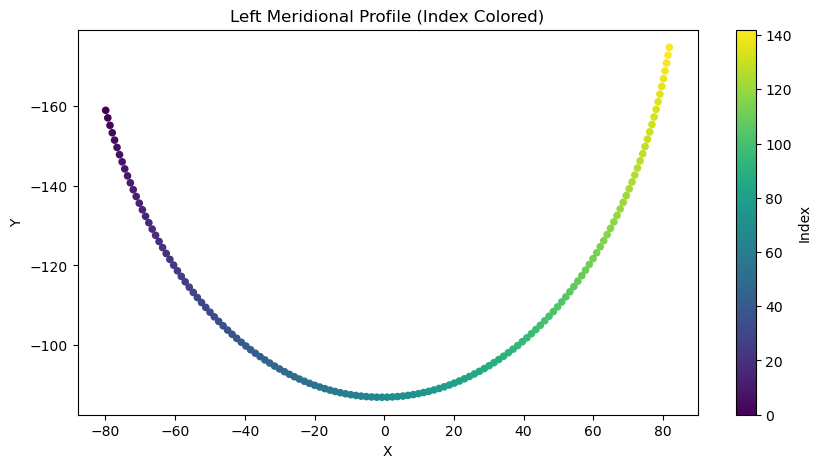

In [ ]:
plt.figure(figsize=(10, 5))
import matplotlib.pyplot as plt

indices = np.arange(left_meriodonal.shape[0])
sc = plt.scatter(left_meriodonal_shifted[0], left_meriodonal_shifted[1], c=indices, cmap='viridis', s=20)
plt.colorbar(sc, label='Index')
plt.title('Left Meridional Profile (Index Colored)')
plt.xlabel('X')
plt.ylabel('Y')
plt.gca().invert_yaxis()
plt.show()

Index out of bounds for curvature calculation.
Index out of bounds for curvature calculation.
Index out of bounds for curvature calculation.
Index out of bounds for curvature calculation.


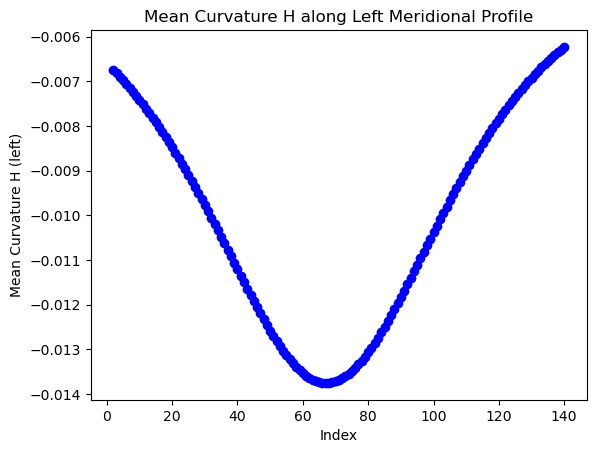

In [ ]:
H_list = []
for idx in range(len(left_meriodonal_shifted[0])):
    left_Kappa = numerical_kappa([left_meriodonal_shifted[0], left_meriodonal_shifted[1]], idx)
    # plt.scatter(idx, left_Kappa, color='r')
    H_left = calculate_mean_curvature([left_meriodonal_shifted[0], left_meriodonal_shifted[1]], idx, left_Kappa)
    plt.scatter(idx, H_left, color='b')
    if H_left is not None:
        H_list.append(H_left)

plt.xlabel('Index')
plt.ylabel('Mean Curvature H (left)')
plt.title('Mean Curvature H along Left Meridional Profile')
plt.show()

In [ ]:
import numpy as np 
print(1/a)
print(np.mean(H_list))

0.007229178393759657
-0.010182087320160429


In [ ]:
if not origin:
    print("distance calculation failed.")
    exit()

data = {
    "filename": os.path.basename(image_path),
    "left_top_angle": None,
    "left_top_Y": None,
    "left_top_X": None,
    "left_bottom_angle": None,
    "left_bottom_Y": None,
    "left_bottom_X": None,
    "right_top_angle": None,
    "right_top_Y": None,
    "right_top_X": None,
    "right_bottom_angle": None,
    "right_bottom_Y": None,
    "right_bottom_X": None,
    "y*": None,
}
Ystar = min_dist / 2 if min_dist else None
data["y*"] = Ystar


# Process contact points and angles
def process_contacts(contacts, side, origin):
    for pos in ["top", "bottom"]:
        contact = contacts.get(pos, {})
        if contact["point"] is not None and contact["angle_deg"] is not None:
            # Transform coordinates
            Xn, Yn = transform_point_to_frame(contact["point"], origin)
            # Store values with absolute angle
            data[f"{side}_{pos}_angle"] = abs(contact["angle_deg"])
            data[f"{side}_{pos}_Y"] = Yn
            data[f"{side}_{pos}_X"] = Xn


if origin:
    process_contacts(left_contacts, "left", origin)
    process_contacts(right_contacts, "right", origin)

results.append(data)


# Transform coordinates
pts_l = ellipse_to_points(*ellipse_left)
pts_r = ellipse_to_points(*ellipse_right)
# Xl, Yl = transform_points_to_new_frame(pts_l[:,0], pts_l[:,1], origin)
# Xr, Yr = transform_points_to_new_frame(pts_r[:,0], pts_r[:,1], origin)

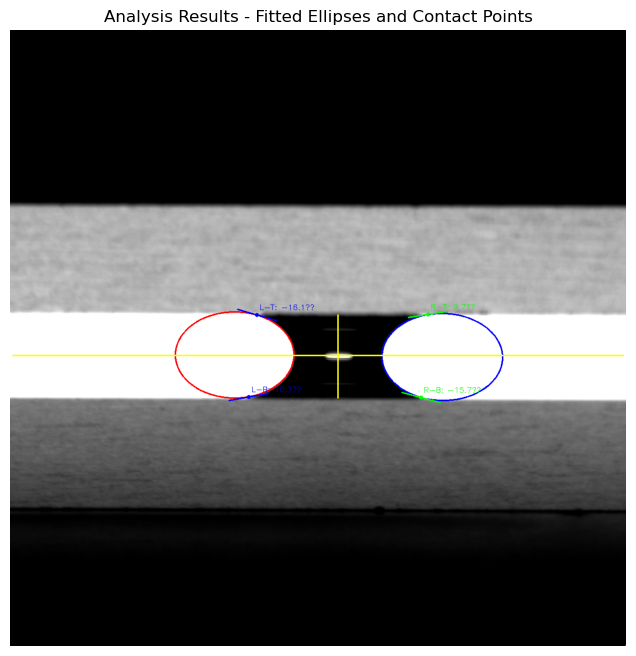

In [ ]:

# Generate debug visualization
debug_img = image.copy()

# Draw fitted ellipses on full image
if ellipse_left is not None:
    (lx, ly), (lma, lmi), lang = ellipse_left
    cv2.ellipse(
        debug_img,
        (int(lx + x_min), int(ly + y_min)),
        (int(lma / 2), int(lmi / 2)),
        lang,
        0,
        360,
        (0, 0, 255),
        2,
    )

if ellipse_right is not None:
    (rx, ry), (rma, rmi), rang = ellipse_right
    cv2.ellipse(
        debug_img,
        (int(rx + x_min), int(ry + y_min)),
        (int(rma / 2), int(rmi / 2)),
        rang,
        0,
        360,
        (255, 0, 0),
        2,
    )

# Draw coordinate axes
origin_full = (int(origin[0] + x_min), int(origin[1] + y_min))
cv2.line(debug_img, (origin_full[0], y_min), (origin_full[0], y_max), (0, 255, 255), 2)
cv2.line(debug_img, (x_min, origin_full[1]), (x_max, origin_full[1]), (0, 255, 255), 2)

# Draw contact points and angles
debug_img = draw_contact_angle_debug(
    debug_img, left_contacts["top"], (x_min, y_min), (255, 0, 0), 0, "L-T: "
)
debug_img = draw_contact_angle_debug(
    debug_img, left_contacts["bottom"], (x_min, y_min), (255, 0, 0), 0, "L-B: "
)
debug_img = draw_contact_angle_debug(
    debug_img, right_contacts["top"], (x_min, y_min), (0, 255, 0), 0, "R-T: "
)
debug_img = draw_contact_angle_debug(
    debug_img, right_contacts["bottom"], (x_min, y_min), (0, 255, 0), 0, "R-B: "
)

# Show results
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(debug_img, cv2.COLOR_BGR2RGB))
plt.title("Analysis Results - Fitted Ellipses and Contact Points")
plt.axis("off")
plt.show()


In [ ]:

# Comprehensive printout
print(f"\n=== Results for {os.path.basename(image_path)} ===")
# transform contact points for below


# Contact points and angles
print("\nIntersection Points and Angles:")
for side, contacts in [("Left", left_contacts), ("Right", right_contacts)]:
    for pos in ["Top", "Bottom"]:
        contact = contacts[pos.lower()]
        pt = contact["point"]
        angle = contact["angle_deg"]

        print(f"\n{side} {pos} Contact:")

        # Handle coordinates
        if pt is not None:
            try:
                x_roi, y_roi = pt  # Explicit unpacking
                Xn, Yn = transform_point_to_frame((x_roi, y_roi), origin)

                # print(f"  Image Coordinates: ({x_roi+x_min:.1f}, {y_roi+y_min:.1f})")
                print(f"  Transformed System: (X={Xn:.1f}, Y={Yn:.1f})")

            except (ValueError, TypeError) as e:
                print(f"  Transformation error: {str(e)}")

        if angle is not None:
            absangle = abs(angle)
            print(f"  Angle: {absangle:+.1f}°")
        else:
            print("  Angle: Could not be calculated")


print("\nGeometric Analysis:")
print(f"Y* (neck width): {Ystar:.2f} px")
print(f"Image origin: ({origin_full[0]:.1f}, {origin_full[1]:.1f})")




=== Results for 240515_AAS_IptmsT_SnOxB_075mm.png ===

Intersection Points and Angles:

Left Top Contact:
  Transformed System: (X=-80.5, Y=-160.7)
  Angle: +16.1°

Left Bottom Contact:
  Transformed System: (X=82.2, Y=-176.6)
  Angle: +10.3°

Right Top Contact:
  Transformed System: (X=-80.9, Y=177.5)
  Angle: +9.7°

Right Bottom Contact:
  Transformed System: (X=83.0, Y=164.0)
  Angle: +15.7°

Geometric Analysis:
Y* (neck width): 87.00 px
Image origin: (647.0, 642.0)


105.95350773103785 161.25501802722562


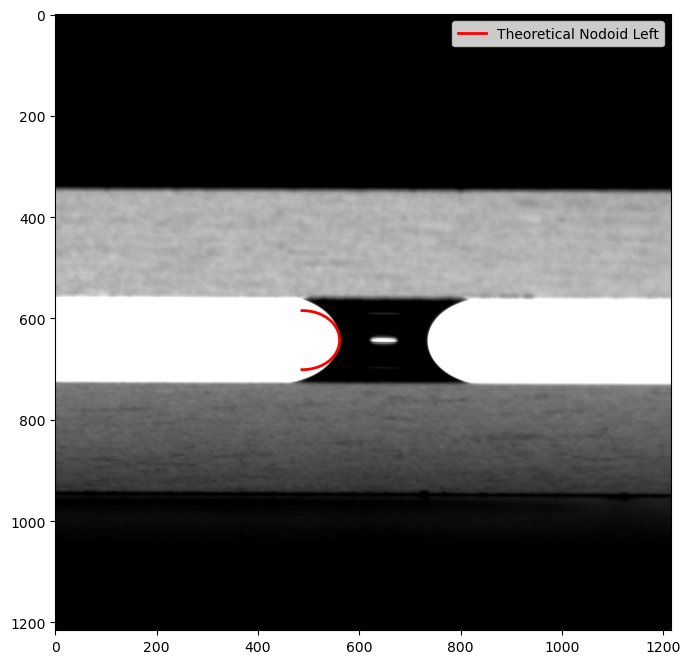

Bridge type: nodoid
Parameters: a=105.95, b=161.26
ROI coords: x=5-1211, y=562-726
Origin point: (647, 642)
138.3283058643588 177.86541407688864


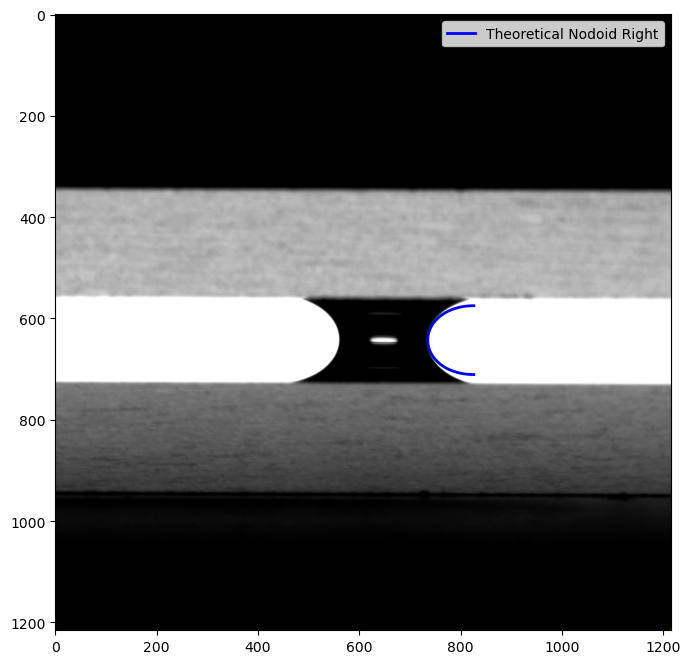

Bridge type: nodoid
Parameters: a=138.33, b=177.87
ROI coords: x=5-1211, y=562-726
Origin point: (647, 642)


In [ ]:


###############################################################################################################################

# Solve for a and b using both contact points' equations


# Known values from image analysis (using absolute values for angles)
for side in ["left", "right"]:
    y_star = data["y*"]
    yc1 = np.abs(data[f"{side}_top_Y"])
    yc2 = np.abs(data[f"{side}_bottom_Y"])
    theta1 = np.deg2rad(
        abs(data[f"{side}_top_angle"])
    )  # Absolute value for angle direction
    theta2 = np.deg2rad(abs(data[f"{side}_bottom_angle"]))

    # After contact angle calculation
    bridge_type = classify_bridge(y_star, yc1, yc2, np.radians(theta1), np.radians(theta2))
    a, b = calculate_parameters(
        bridge_type, y_star, yc1, yc2, np.radians(theta1), np.radians(theta2)
    )
    print(a, b)
    H = get_H_from_nodoid_or_unduloid(a, bridge_type)
    
    # Get experimental points for error cal pfig, ax = plt.subplots(figsize=(12, 8))r ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))man processing loop:
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

    # Store all plottable artists
    # In your main processing loop:
    # In your plotting section:
    artists = []
    theory_line = draw_theoretical_curve(
        ax, bridge_type, a, b, origin, (x_min, y_min, x_max, y_max), side
    )

    if theory_line is not None:
        # Add theoretical curve
        color = "red" if side == "left" else "blue"
        theory_line = ax.plot(
            theory_line[1],
            theory_line[0],
            c=color,
            lw=2,
            label=f"Theoretical {bridge_type.capitalize()} {side.capitalize()}",
        )
        artists.append(theory_line[0])


    # Create legend only if we have entries
    if artists:
        ax.legend(handles=artists)
    else:
        ax.text(
            0.5,
            0.5,
            "No Valid Theoretical Curve",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )

    plt.show()
    # After parameter calculation
    print(f"Bridge type: {bridge_type}")
    print(f"Parameters: a={a:.2f}, b={b:.2f}")
    print(f"ROI coords: x={x_min}-{x_max}, y={y_min}-{y_max}")
    print(f"Origin point: {origin_full}")